### BPASSSource vs BlackBodySource: `photo_thin_table` and `photo_thick_table`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as cst
import astropy.units as u

from pyc2ray.radiation.blackbody import BlackBodySource, BPASSSource
from pyc2ray.radiation.common import make_tau_table

### Physical constants (ionisation edges)

In [2]:
E_HI   = 13.598 * u.eV
E_HeI  = 24.587 * u.eV
E_HeII = 54.416 * u.eV
 
FREQ_HI   = (E_HI   / cst.h).to(u.Hz)
FREQ_HeI  = (E_HeI  / cst.h).to(u.Hz)
FREQ_HeII = (E_HeII / cst.h).to(u.Hz)
 
LAMB_HI   = (cst.c / FREQ_HI  ).to(u.AA)
LAMB_HeI  = (cst.c / FREQ_HeI ).to(u.AA)
LAMB_HeII = (cst.c / FREQ_HeII).to(u.AA)

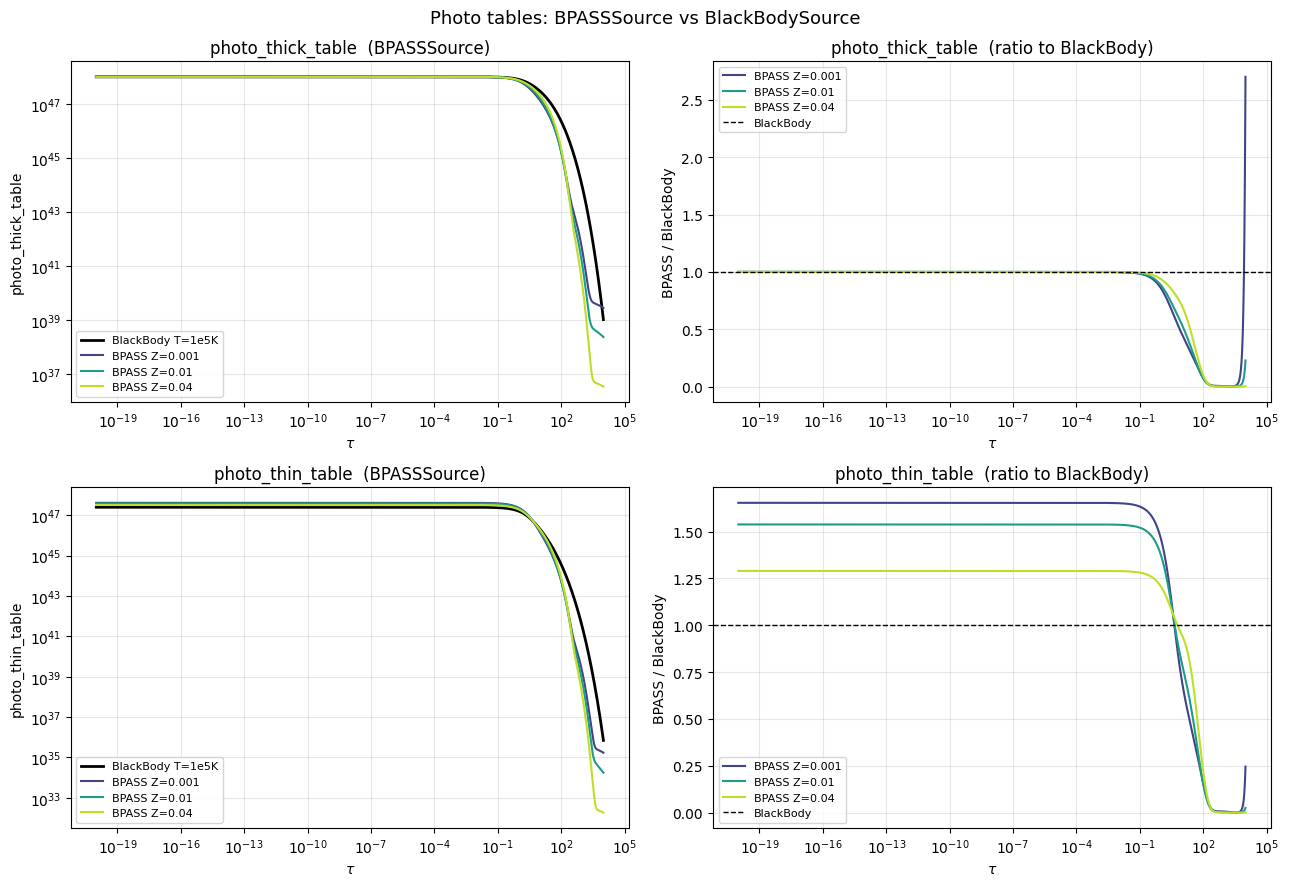

In [3]:
# -----------------------------------------------------------------------
# Setup
# -----------------------------------------------------------------------

minlogtau, maxlogtau, NumTau = -20.0, 4.0, 20000
tau, dlogtau = make_tau_table(minlogtau, maxlogtau, NumTau)

freq_min     = (13.598 * u.eV / cst.h).to("Hz").value
freq_max     = 10 * (54.416 * u.eV / cst.h).to("Hz").value
S_star_ref   = 1e48

bpass_dir    = "/users/cprior/bpass/bpass_v2.2.1_imf135_300/"
log_age_bins = np.arange(6.0, 7.1, 0.1)

# -----------------------------------------------------------------------
# Compute tables
# -----------------------------------------------------------------------

# BlackBodySource reference
bb = BlackBodySource(1e5, grey=False, freq0=freq_min, pl_index=2.8)
bb_thin, bb_thick = bb.make_photo_table(tau, freq_min, freq_max, S_star_ref)

# BPASSSource at several metallicities
metallicities = [0.001, 0.010, 0.040]
bpass_tables  = {}
for Z in metallicities:
    src = BPASSSource(
        metallicity  = Z,
        age          = 1e7,
        bpass_dir    = bpass_dir,
        grey         = False,
        freq0        = freq_min,
        pl_index     = 2.8,
        log_age_bins = log_age_bins,
    )
    bpass_tables[Z] = src.make_photo_table(tau, freq_min, freq_max, S_star_ref)

# -----------------------------------------------------------------------
# Plot
# -----------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ax_thick, ax_thin = axes[0], axes[1]

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(metallicities)))

# --- absolute values ---
for ax, (bb_table, label) in zip(
    [ax_thick[0], ax_thin[0]],
    [(bb_thick, "thick"), (bb_thin, "thin")]
):
    ax.loglog(tau[1:], bb_table[1:], "k-", lw=2, label="BlackBody T=1e5K")
    for (Z, (t, tk)), c in zip(bpass_tables.items(), colors):
        table = tk if label == "thick" else t
        ax.loglog(tau[1:], table[1:], color=c, lw=1.5, label=f"BPASS Z={Z}")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(f"photo_{label}_table")
    ax.set_title(f"photo_{label}_table  (BPASSSource)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which="both")

# --- ratio to BlackBody ---
for ax, (bb_table, label) in zip(
    [ax_thick[1], ax_thin[1]],
    [(bb_thick, "thick"), (bb_thin, "thin")]
):
    for (Z, (t, tk)), c in zip(bpass_tables.items(), colors):
        table = tk if label == "thick" else t
        ratio = table / bb_table
        ax.semilogx(tau[1:], ratio[1:], color=c, lw=1.5, label=f"BPASS Z={Z}")
    ax.axhline(1, color="k", lw=1, ls="--", label="BlackBody")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(f"BPASS / BlackBody")
    ax.set_title(f"photo_{label}_table  (ratio to BlackBody)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, which="both")

plt.suptitle("Photo tables: BPASSSource vs BlackBodySource", fontsize=13)
plt.tight_layout()
plt.savefig("photo_tables_comparison.png", dpi=150)
plt.show()

### BPASSSource vs BlackBodySource: `photo_thin_table` and `photo_thick_table` with frequency limits

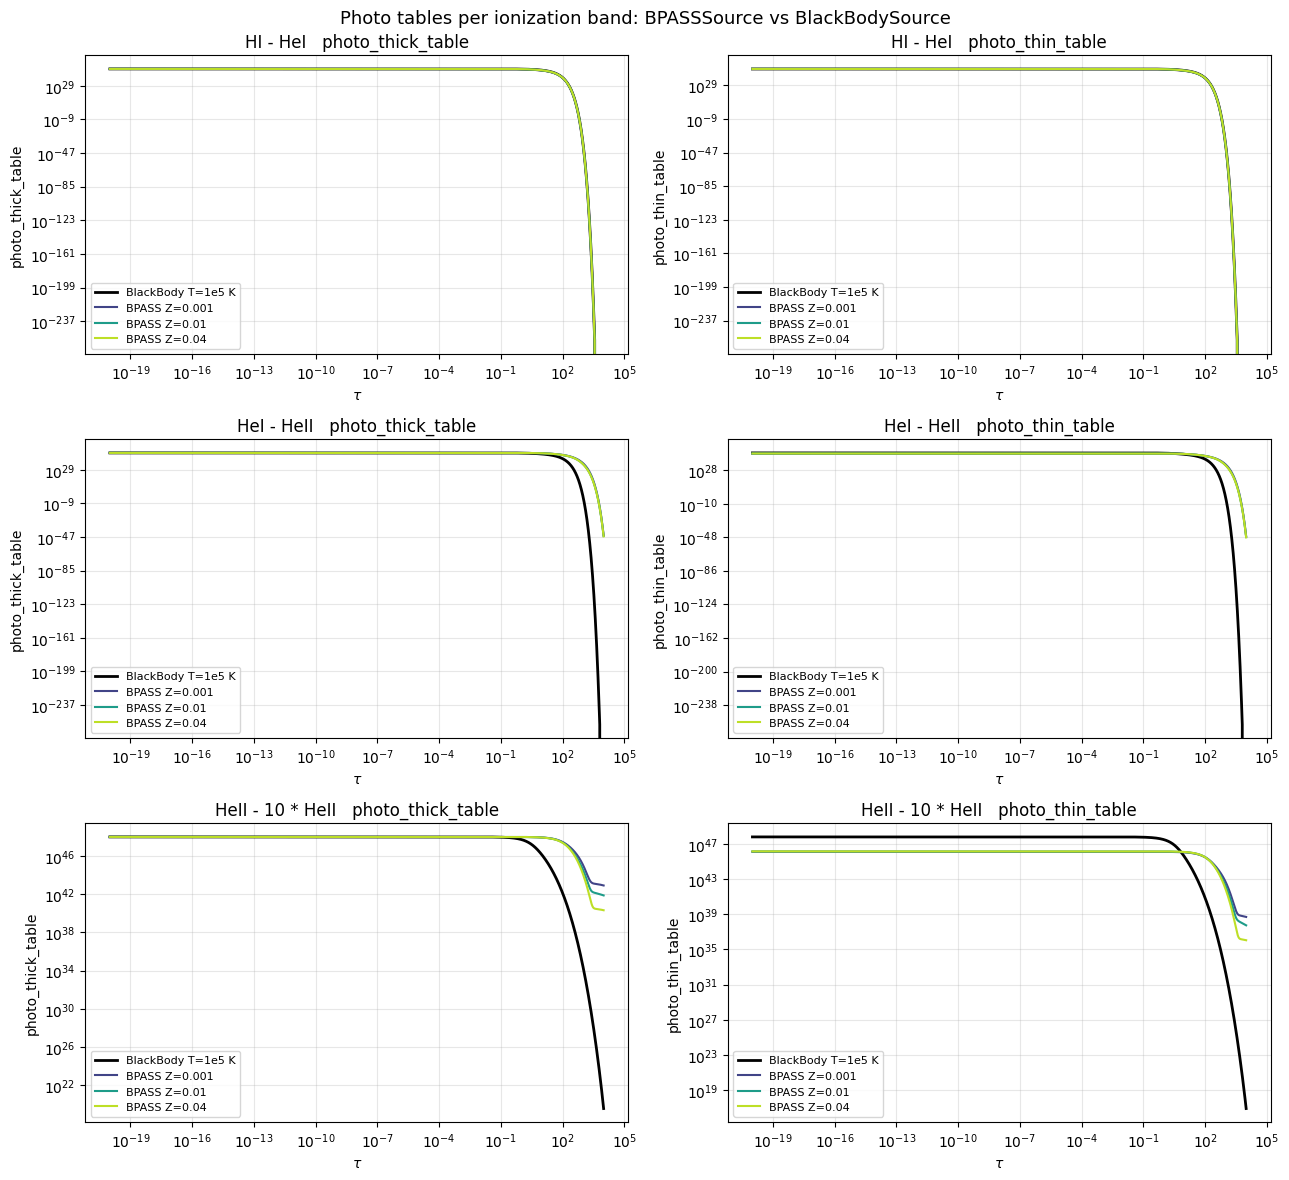

In [10]:
FREQ_HI   = (E_HI   / cst.h).to(u.Hz).value
FREQ_HeI  = (E_HeI  / cst.h).to(u.Hz).value
FREQ_HeII = (E_HeII / cst.h).to(u.Hz).value

# Three frequency bands: (label, freq_lo, freq_hi)
BANDS = [
    ("HI - HeI",    FREQ_HI,   FREQ_HeI),
    ("HeI - HeII",  FREQ_HeI,  FREQ_HeII),
    ("HeII - 10 * HeII", FREQ_HeII, 10 * FREQ_HeII),
]

# -----------------------------------------------------------------------
# Setup
# -----------------------------------------------------------------------
minlogtau, maxlogtau, NumTau = -20.0, 4.0, 20000
tau, dlogtau = make_tau_table(minlogtau, maxlogtau, NumTau)

S_star_ref   = 1e48
bpass_dir    = "/users/cprior/bpass/bpass_v2.2.1_imf135_300/"
log_age_bins = np.arange(6.0, 7.1, 0.1)

metallicities = [0.001, 0.010, 0.040]

# -----------------------------------------------------------------------
# Compute tables for each band
# -----------------------------------------------------------------------
# Per-band storage:
#   bb_tables[band]    = (thin, thick)
#   bpass_tables[band] = {Z: (thin, thick)}
bb_tables    = {}
bpass_tables = {band[0]: {} for band in BANDS}

# Build BPASS sources once per metallicity (reuse across bands)
bpass_sources = {}
for Z in metallicities:
    bpass_sources[Z] = BPASSSource(
        metallicity  = Z,
        age          = 1e7,
        bpass_dir    = bpass_dir,
        grey         = False,
        freq0        = FREQ_HI,
        pl_index     = 2.8,
        log_age_bins = log_age_bins,
    )

for label, f_lo, f_hi in BANDS:
    # BlackBody reference for this band (freq0 set to band's lower edge)
    bb = BlackBodySource(1e5, grey=False, freq0=f_lo, pl_index=2.8)
    bb_tables[label] = bb.make_photo_table(tau, f_lo, f_hi, S_star_ref)

    for Z, src in bpass_sources.items():
        bpass_tables[label][Z] = src.make_photo_table(tau, f_lo, f_hi, S_star_ref)

# -----------------------------------------------------------------------
# Plot: 3 rows (one per band) x 2 cols (thick, thin)
# -----------------------------------------------------------------------
fig, axes = plt.subplots(len(BANDS), 2, figsize=(13, 4 * len(BANDS)))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(metallicities)))

for row, (label, f_lo, f_hi) in enumerate(BANDS):
    bb_thin, bb_thick = bb_tables[label]
    ax_thick = axes[row, 0]
    ax_thin  = axes[row, 1]

    for ax, bb_table, kind in [
        (ax_thick, bb_thick, "thick"),
        (ax_thin,  bb_thin,  "thin"),
    ]:
        ax.loglog(tau[1:], bb_table[1:], "k-", lw=2, label="BlackBody T=1e5 K")
        for (Z, (t, tk)), c in zip(bpass_tables[label].items(), colors):
            table = tk if kind == "thick" else t
            ax.loglog(tau[1:], table[1:], color=c, lw=1.5, label=f"BPASS Z={Z}")

        ax.set_xlabel(r"$\tau$")
        ax.set_ylabel(f"photo_{kind}_table")
        ax.set_title(f"{label}   photo_{kind}_table")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3, which="both")

plt.suptitle("Photo tables per ionization band: BPASSSource vs BlackBodySource",
             fontsize=13)
plt.tight_layout()
plt.show()